In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

from data.loader import load_openml_data, preprocess_after_split
from data.missing_data import generate_mcar, generate_mar1, generate_mar2, generate_mnar
from models.unlabeled_lr import UnlabeledLogReg, run_naive, run_oracle, evaluate

DATASETS = {
    "Spambase": 44,
    "Musk V2": 46615,
    "telescope": 1120,
    "Madelon": 1485
}

In [3]:
results = []

for ds_name, ds_id in DATASETS.items():
    print(f"\n--- Evaluating: {ds_name} (ID: {ds_id}) ---")
    
    X, y = load_openml_data(ds_id)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_valid, y_true_train, y_valid = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    )

    X_train_for_missingness, X_train, X_valid, X_test = preprocess_after_split(X_train, X_valid, X_test)



    oracle_metrics = run_oracle(X_train, y_true_train, X_valid, y_valid, X_test, y_test)
    res_oracle = {
        "Dataset": ds_name, "Scheme": "Oracle", "Parameter": 0.0, 
        "Actual_Missing_Rate": 0.0, "Method": "Oracle"
    }
    res_oracle.update(oracle_metrics)
    results.append(res_oracle)

    scenarios = []

    for c in [0.1, 0.3, 0.5, 0.7, 0.9]:
        y_obs = generate_mcar(X_train_for_missingness, y_true_train, c=c)
        scenarios.append(('MCAR', c, y_obs))

    y_obs_mar1 = generate_mar1(X_train_for_missingness, y_true_train)
    scenarios.append(('MAR1', 'default', y_obs_mar1))

    y_obs_mar2 = generate_mar2(X_train_for_missingness, y_true_train, bias=-0.5)
    scenarios.append(('MAR2', 'default', y_obs_mar2))

    y_obs_mnar = generate_mnar(X_train_for_missingness, y_true_train, ratio=0.7, gamma=3.0)
    scenarios.append(('MNAR', 'default', y_obs_mnar))

    for scheme_name, param, y_obs_train in tqdm(scenarios, desc=f"Scenario for {ds_name}"):
        actual_missing_rate = (y_obs_train == -1).mean()

        naive_metrics = run_naive(X_train, y_obs_train, X_valid, y_valid, X_test, y_test)
        
        model_lp = UnlabeledLogReg(completion="label_prop_cne", lp_kernel="knn", lp_n_neighbors=5)
        model_lp.fit(X_train, y_obs_train, X_valid, y_valid)
        lp_metrics = evaluate(y_test, model_lp.predict_proba(X_test))

        model_sp = UnlabeledLogReg(completion="sportisse_em")
        model_sp.fit(X_train, y_obs_train, X_valid, y_valid)
        sp_metrics = evaluate(y_test, model_sp.predict_proba(X_test))

        for method_name, metrics in [
            ("Naive", naive_metrics),
            ("LabelProp_CNe", lp_metrics),
            ("Sportisse_EM", sp_metrics)
        ]:
            res = {
                "Dataset": ds_name, "Scheme": scheme_name, "Parameter": param,
                "Actual_Missing_Rate": actual_missing_rate, "Method": method_name
            }
            res.update(metrics)
            results.append(res)

df_results = pd.DataFrame(results)
df_results.to_csv("task3_results_test.csv", index=False)
print("Saved the results to task3_results_test.csv")


--- Evaluating: Spambase (ID: 44) ---


Scenario for Spambase:  62%|██████▎   | 5/8 [01:07<00:40, 13.42s/it]


KeyboardInterrupt: 

### Visualizations

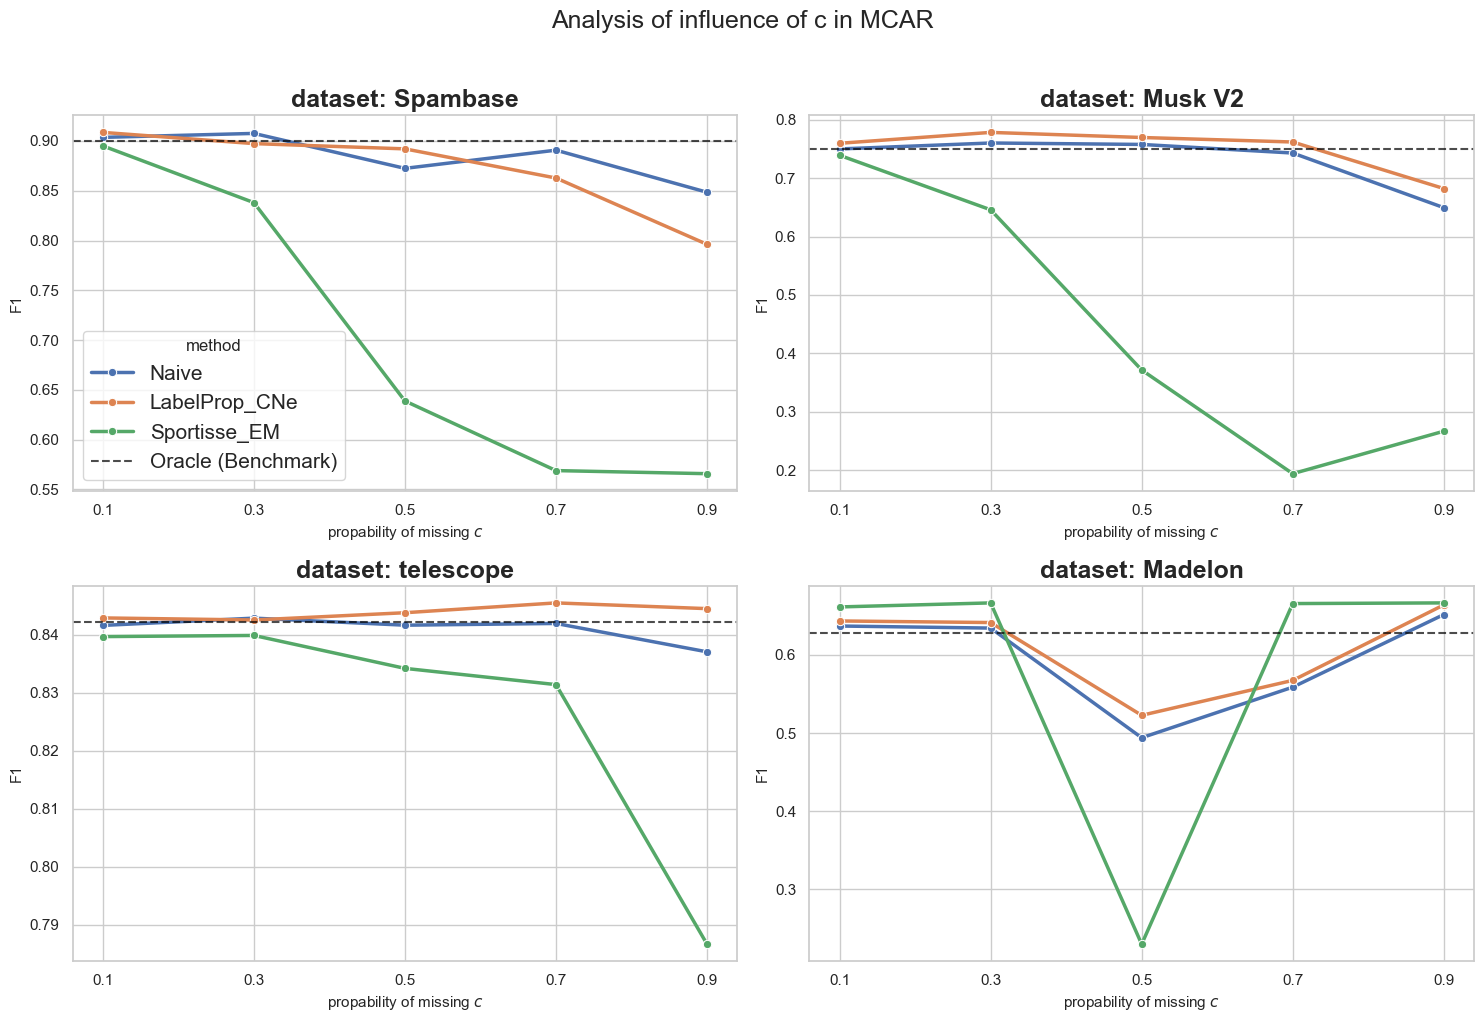

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("task3_results_small.csv")

mcar_data = df[df['Scheme'].isin(['MCAR', 'Oracle'])].copy()

datasets = mcar_data['Dataset'].unique()
metric = 'f1' 

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, ds in enumerate(datasets):
    if i >= len(axes_flat):
        break 
        
    ax = axes_flat[i]
    ds_data = mcar_data[mcar_data['Dataset'] == ds]
    
    sns.lineplot(
        data=ds_data[ds_data['Scheme'] == 'MCAR'], 
        x='Parameter', 
        y=metric, 
        hue='Method', 
        marker='o',
        linewidth=2.5,
        ax=ax
    )

    oracle_val = ds_data[ds_data['Method'] == 'Oracle'][metric].mean()
    ax.axhline(oracle_val, ls='--', color='black', label='Oracle (Benchmark)', alpha=0.7)
    
    ax.set_title(f"dataset: {ds}", fontsize=18, fontweight='bold')
    ax.set_xlabel("propability of missing $c$", fontsize=11)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
    
    if i == 0:
        ax.legend(title="method", loc='best', fontsize = 15)
    else:
        ax.get_legend().remove()

plt.suptitle(f"Analysis of influence of c in MCAR", 
             fontsize=18, y=1.02)

plt.tight_layout()
plt.savefig("mcar_analysis_grid_2x2.png", dpi=300, bbox_inches='tight')
plt.show()

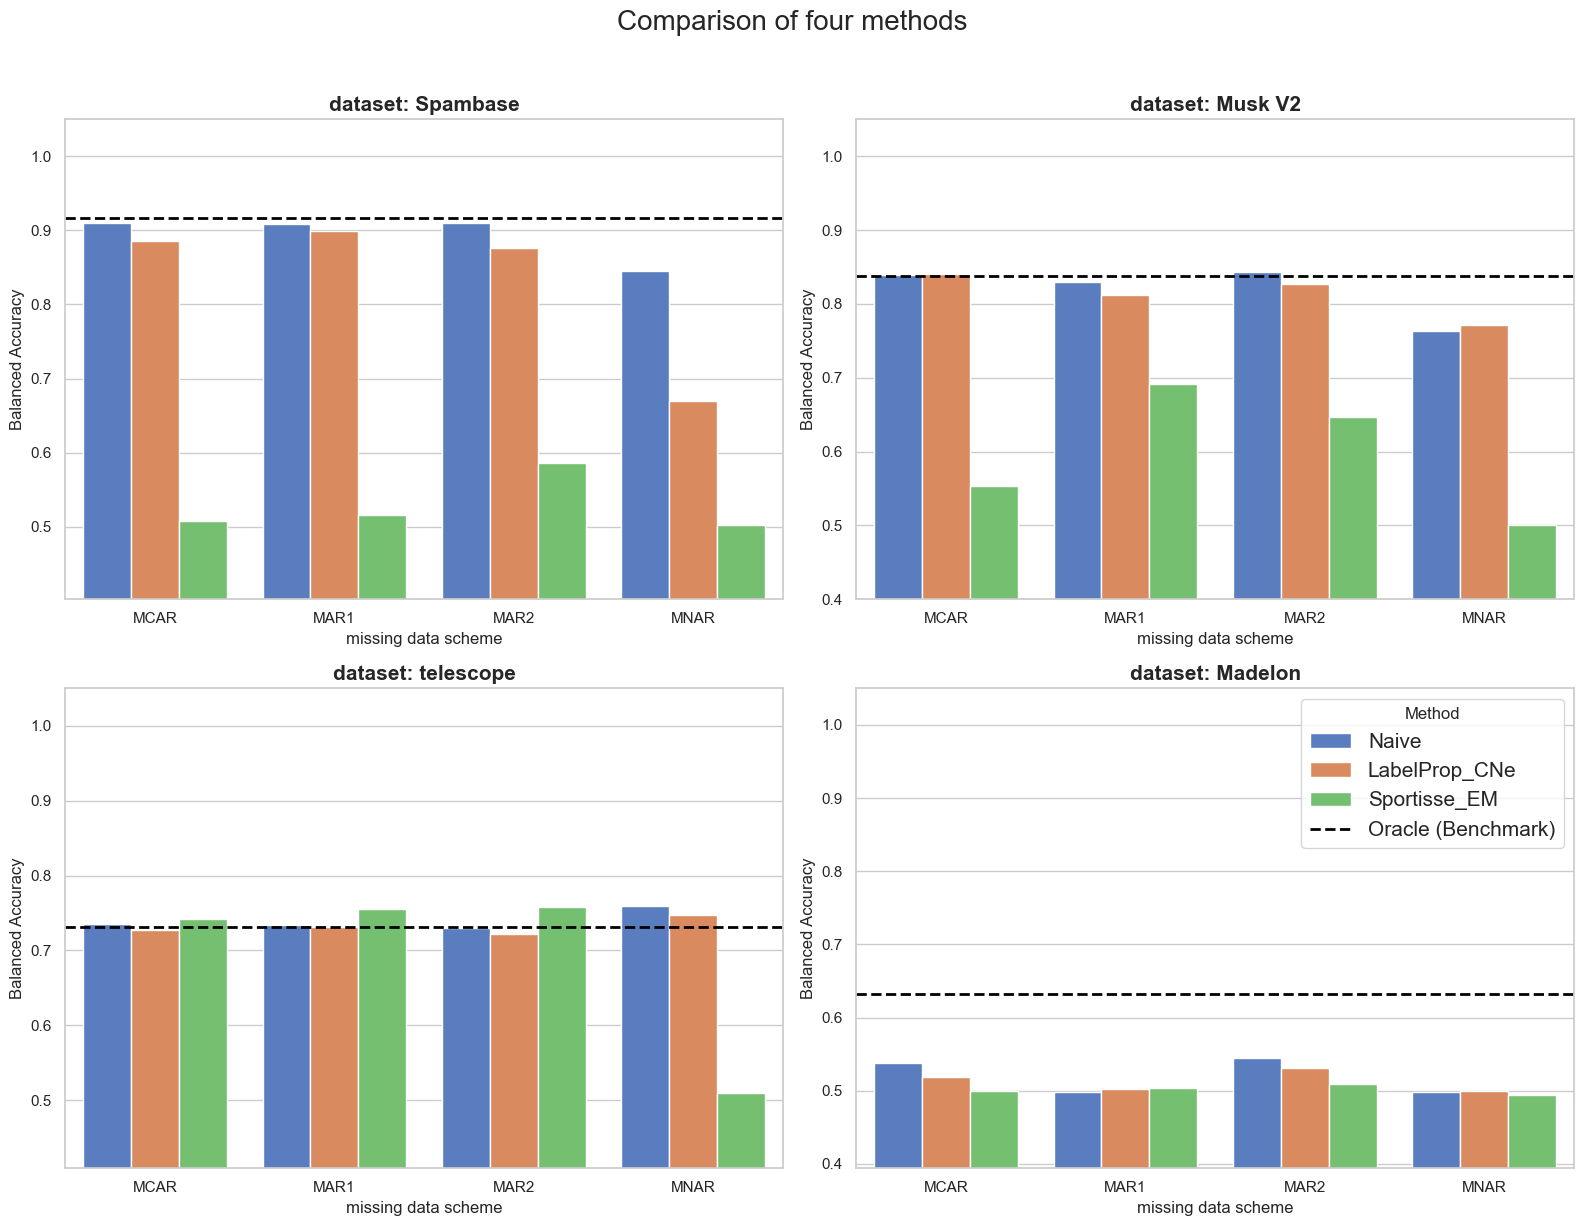

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("task3_results_small.csv")


df_comp = df[
    ((df['Scheme'] == 'MCAR') & (df['Parameter'] == '0.7')) |
    (df['Scheme'].isin(['MAR1', 'MAR2', 'MNAR']))
].copy()

oracle_data = df[df['Method'] == 'Oracle'].copy()

datasets = df_comp['Dataset'].unique()
metric = 'balanced_accuracy'  

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, ds in enumerate(datasets):
    if i >= len(axes_flat):
        break
        
    ax = axes_flat[i]
    ds_data = df_comp[df_comp['Dataset'] == ds]
    

    sns.barplot(
        data=ds_data,
        x='Scheme',
        y=metric,
        hue='Method',
        palette='muted',
        ax=ax,
        order=['MCAR', 'MAR1', 'MAR2', 'MNAR']
    )
    
    oracle_val = oracle_data[oracle_data['Dataset'] == ds][metric].mean()
    ax.axhline(oracle_val, ls='--', color='black', label='Oracle (Benchmark)', linewidth=2)
    
    ax.set_title(f"dataset: {ds}", fontsize=15, fontweight='bold')
    ax.set_xlabel("missing data scheme", fontsize=12)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    
    min_val = min(ds_data[metric].min(), oracle_val)
    ax.set_ylim(max(0, min_val - 0.1), 1.05)
    
    # Legend
    if i == 3:
        ax.legend(title="Method", loc='upper right', fontsize=15)
    else:
        ax.get_legend().remove()

plt.suptitle(f"Comparison of four methods", 
             fontsize=20, y=1.02)

plt.tight_layout()
plt.savefig("schemes_comparison_grid_2x2.png", dpi=300, bbox_inches='tight')
plt.show()